# Credit Card Fraud Detection with Neural Network

This notebook demonstrates credit card fraud detection using a neural network. It includes data exploration, visualization, model training, and evaluation.

In [1]:
# Import Libraries and Download Dataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
import requests
from tensorflow import keras
from tensorflow.keras import layers

# Download dataset if not present
DATA_URL = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
DATA_PATH = "creditcard.csv"
if not os.path.exists(DATA_PATH):
    print("Downloading credit card fraud dataset...")
    r = requests.get(DATA_URL)
    with open(DATA_PATH, "wb") as f:
        f.write(r.content)
    print("Download complete.")
else:
    print("Dataset already exists.")

2025-07-29 00:27:48.571705: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-29 00:27:48.575234: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-29 00:27:48.584307: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753748868.598671   11493 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753748868.602971   11493 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753748868.615931   11493 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

Dataset already exists.


In [2]:
# Load and Explore Data
df = pd.read_csv(DATA_PATH)
print("Data loaded. Shape:", df.shape)
df.head()

Data loaded. Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


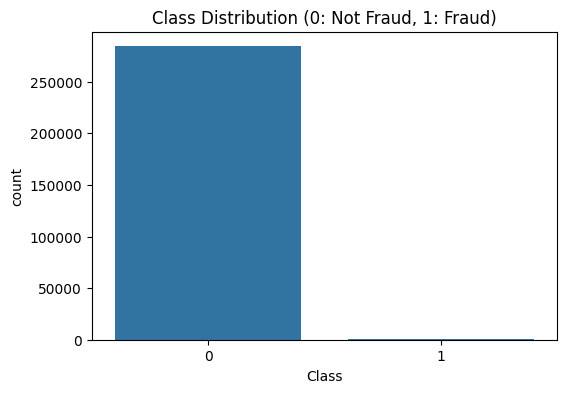

Class counts:
Class
0    284315
1       492
Name: count, dtype: int64


In [3]:
# Visualize Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0: Not Fraud, 1: Fraud)')
plt.show()
print('Class counts:')
print(df['Class'].value_counts())

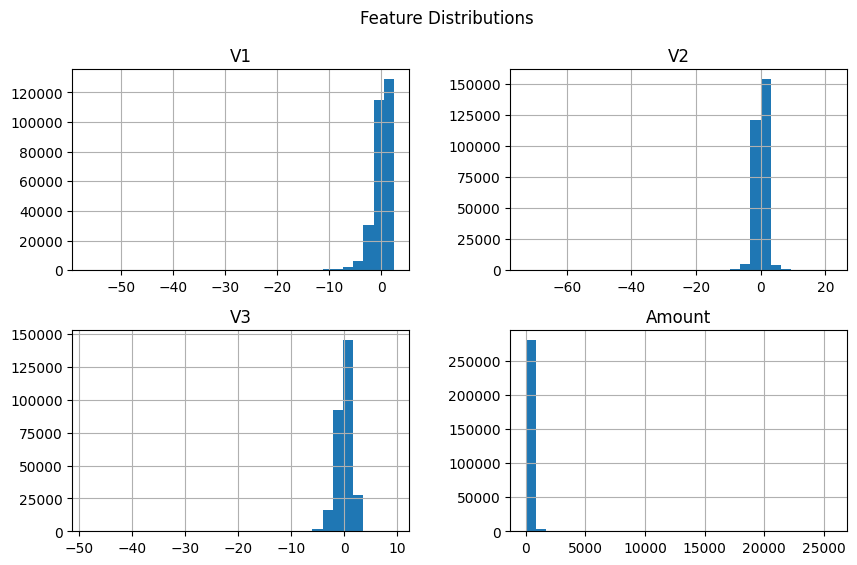

In [4]:
# Visualize Feature Distributions
sample_features = ['V1', 'V2', 'V3', 'Amount']
df[sample_features].hist(bins=30, figsize=(10,6))
plt.suptitle('Feature Distributions')
plt.show()

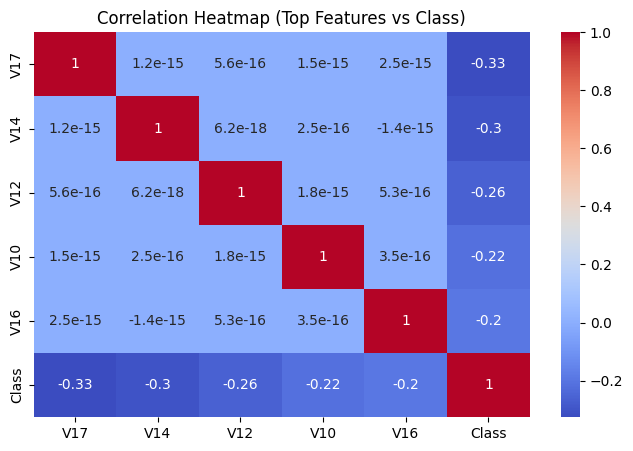

In [5]:
# Correlation Heatmap of Top Features
correlations = df.corr()['Class'].abs().sort_values(ascending=False)
top_corr_features = correlations[1:6].index.tolist()  # Exclude 'Class' itself
plt.figure(figsize=(8,5))
sns.heatmap(df[top_corr_features + ['Class']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Top Features vs Class)')
plt.show()

In [6]:
# Prepare Features and Labels
X = df.drop(["Class"], axis=1).values
y = df["Class"].values

In [7]:
# Train/Test Split and Feature Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# Build Neural Network Model
model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/workspaces/Projects/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-07-29 00:28:01.093416: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Train the Model
print("Training the model...")
history = model.fit(X_train, y_train, epochs=5, batch_size=2048, validation_split=0.1, verbose=1)

2025-07-29 00:28:01.272089: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 24607200 exceeds 10% of free system memory.


Training the model...
Epoch 1/5
Epoch 1/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9972 - loss: 0.2338 - val_accuracy: 0.9980 - val_loss: 0.0212
Epoch 2/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9972 - loss: 0.2338 - val_accuracy: 0.9980 - val_loss: 0.0212
Epoch 2/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9983 - loss: 0.0164 - val_accuracy: 0.9980 - val_loss: 0.0080
Epoch 3/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9983 - loss: 0.0164 - val_accuracy: 0.9980 - val_loss: 0.0080
Epoch 3/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9983 - loss: 0.0082 - val_accuracy: 0.9984 - val_loss: 0.0055
Epoch 4/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9983 - loss: 0.0082 - val_accuracy: 0.9984 - val_loss: 0.0055
Epoch 4/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9986 - loss: 0.0056 - val_accuracy: 0.9991 - val_loss: 0.0040
Epoch 5/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9986 - loss: 0

In [10]:
# Evaluate Model Performance
print("Evaluating on test set...")
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Accuracy: {accuracy:.4f}")

Evaluating on test set...
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9994 - loss: 0.0031
Test Accuracy: 0.9992
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9994 - loss: 0.0031
Test Accuracy: 0.9992


In [11]:
# Generate Classification Report and Confusion Matrix
y_pred = (model.predict(X_test) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 757us/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 757us/step

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.68      0.75        98

    accuracy                           1.00     56962
   macro avg       0.92      0.84      0.88     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56851    13]
 [   31    67]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.68      0.75        98

    accuracy                           1.00     56962
   macro avg       0.92      0.84      0.88     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56851    13]
 [   31    67]]
